## **# ApexPlanet Internship - Task 2**
## Exploratory Data Analysis and Business Intelligence.
### Business Objective
The objective of this task is to perform exploratory data analysis on the cleaned Superstore retail dataset to uncover sales trends, profitability insights, and operational performance patterns for strategic business intelligence.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("task1_cleaned_superstore.csv", parse_dates=["order_date", "ship_date"])
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub_category,product_name,sales,quantity,discount,profit,delivery_days,profit_margin,sales_bucket
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,16.00,Medium
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,30.00,High
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,47.00,Low
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-40.00,High
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,11.25,Low


In [3]:
df.shape

(9994, 24)

In [4]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'delivery_days', 'profit_margin', 'sales_bucket'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub_category   9994 n

# Sales Analysis

###This step analyzes how sales values are distributed to identify transaction patterns and outliers.

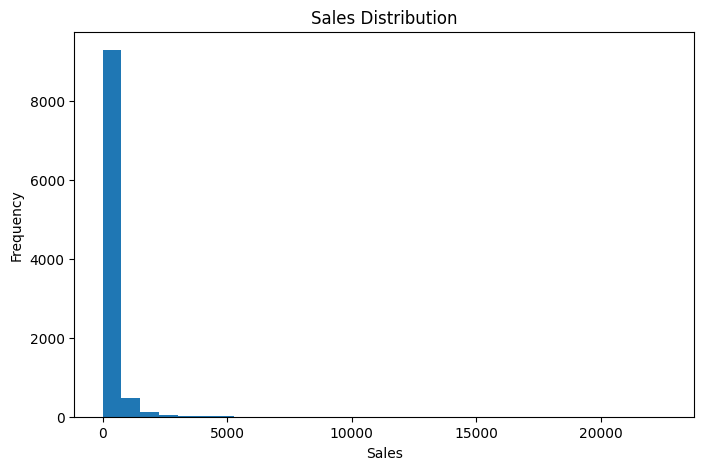

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

### Observation
Most sales transactions are concentrated in the lower range, while a few high-value transactions act as outliers.

## Profit Analysis

##  Profit Distribution Analysis
This step evaluates profit trends and identifies loss-making transactions.

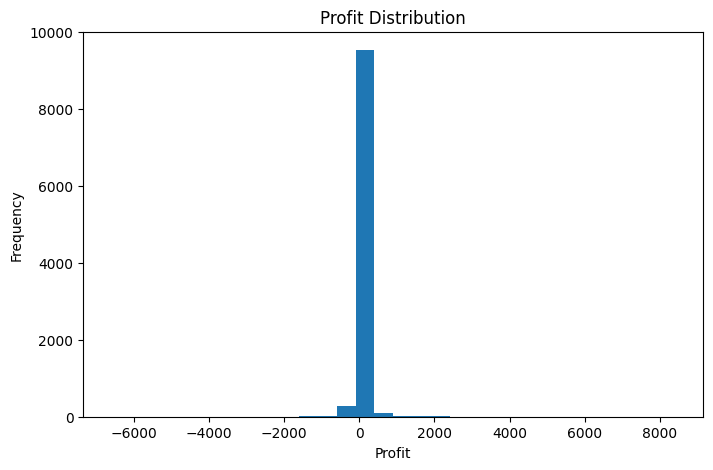

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["profit"], bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

### Observation
The profit distribution shows both positive and negative values, indicating that some transactions result in losses.

# **Category Analysis**

##  Category-wise Analysis
This step identifies which product categories contribute most to overall sales.

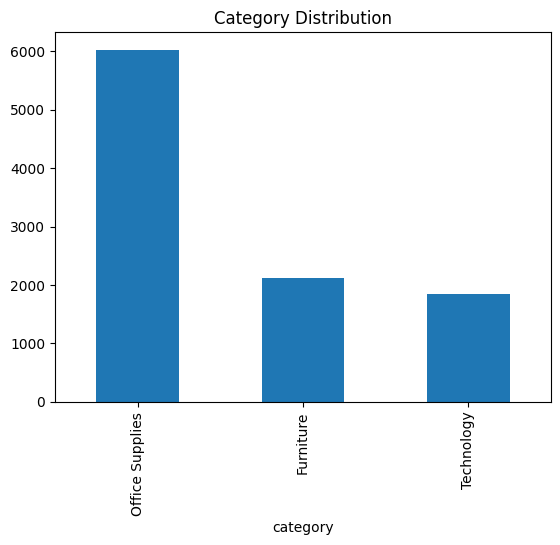

In [8]:
df["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.show()

### Observation
The dataset is dominated by a few product categories, indicating uneven distribution of transactions across categories.

# **Region Analysis**

## Region-wise Analysis
This step analyzes the distribution of sales across different regions.

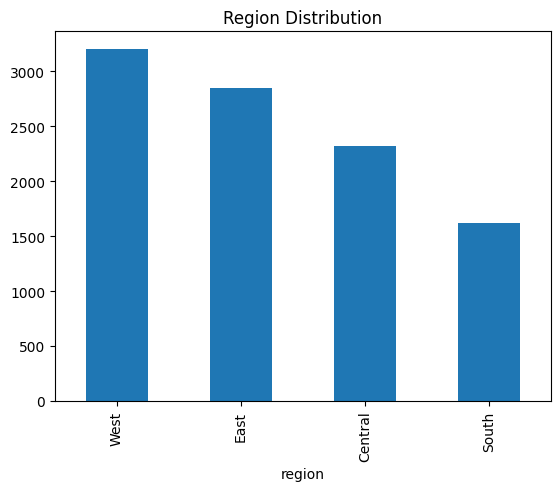

In [9]:
df["region"].value_counts().plot(kind="bar")
plt.title("Region Distribution")
plt.show()

### Observation
Sales are distributed across multiple regions, with certain regions contributing more transactions than others.

# **Correlation Analysis**

##  Correlation Analysis
This step identifies relationships between numerical variables such as sales, profit, discount, and quantity.

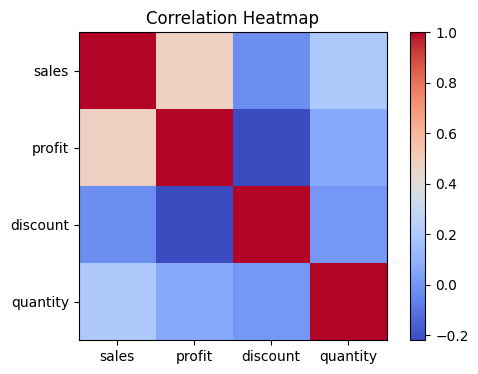

In [10]:
import matplotlib.pyplot as plt

corr = df[["sales", "profit", "discount", "quantity"]].corr()

plt.figure(figsize=(6,4))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

# **Sales vs Profit**

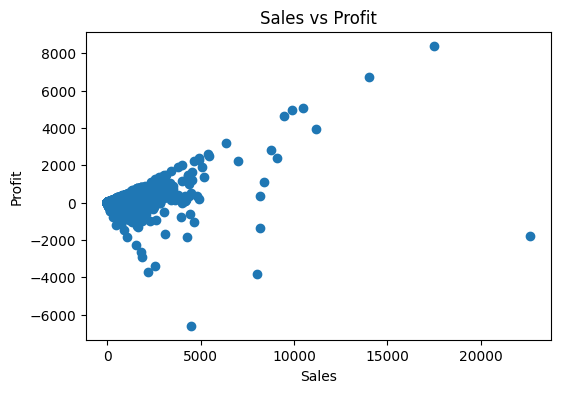

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df["sales"], df["profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

# **Category vs Profit**

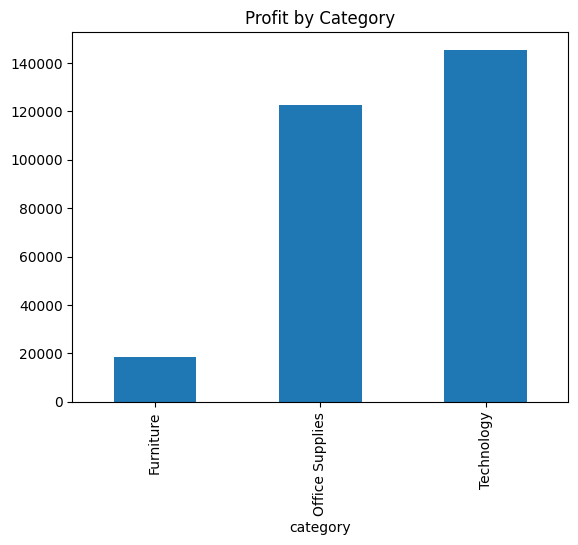

In [12]:
df.groupby("category")["profit"].sum().plot(kind="bar")
plt.title("Profit by Category")
plt.show()

# **Region vs Sales**

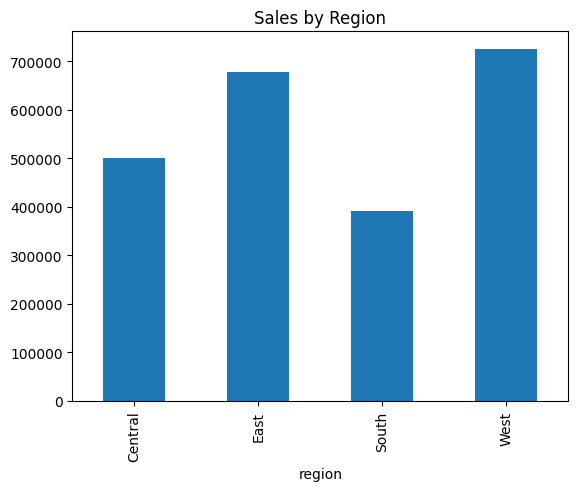

In [13]:
df.groupby("region")["sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.show()

### Observation
Some regions generate significantly higher sales, indicating strong market performance in those areas.

# **SQL**

In [14]:
import sqlite3

conn = sqlite3.connect("superstore.db")

In [15]:
df.to_sql("sales", conn, if_exists="replace", index=False)

9994

## **Basic SQL Queries**

**Total Sales**

In [16]:
pd.read_sql("""
SELECT SUM(sales) AS total_sales
FROM sales;
""", conn)

,total_sales
0,2.297201e+06


**Total Profit**

In [17]:
pd.read_sql("""
SELECT SUM(profit) AS total_profit
FROM sales;
""", conn)

,total_profit
0,286397.0217


**Sales by Category**

In [18]:
pd.read_sql("""
SELECT category, SUM(sales) AS total_sales
FROM sales
GROUP BY category
ORDER BY total_sales DESC;
""", conn)

,category,total_sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


**Profit by Region**

In [19]:
pd.read_sql("""
SELECT region, SUM(profit) AS total_profit
FROM sales
GROUP BY region
ORDER BY total_profit DESC;
""", conn)

,region,total_profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


**Top 5 Customers**

In [20]:
pd.read_sql("""
SELECT customer_name, SUM(sales) AS total_spent
FROM sales
GROUP BY customer_name
ORDER BY total_spent DESC
LIMIT 5;
""", conn)

,customer_name,total_spent
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571


##  SQL-Based Business Analysis
SQL queries are used to extract key business insights such as total sales, profit distribution, and top-performing customers.

# **POWER BI DASHBOARD**

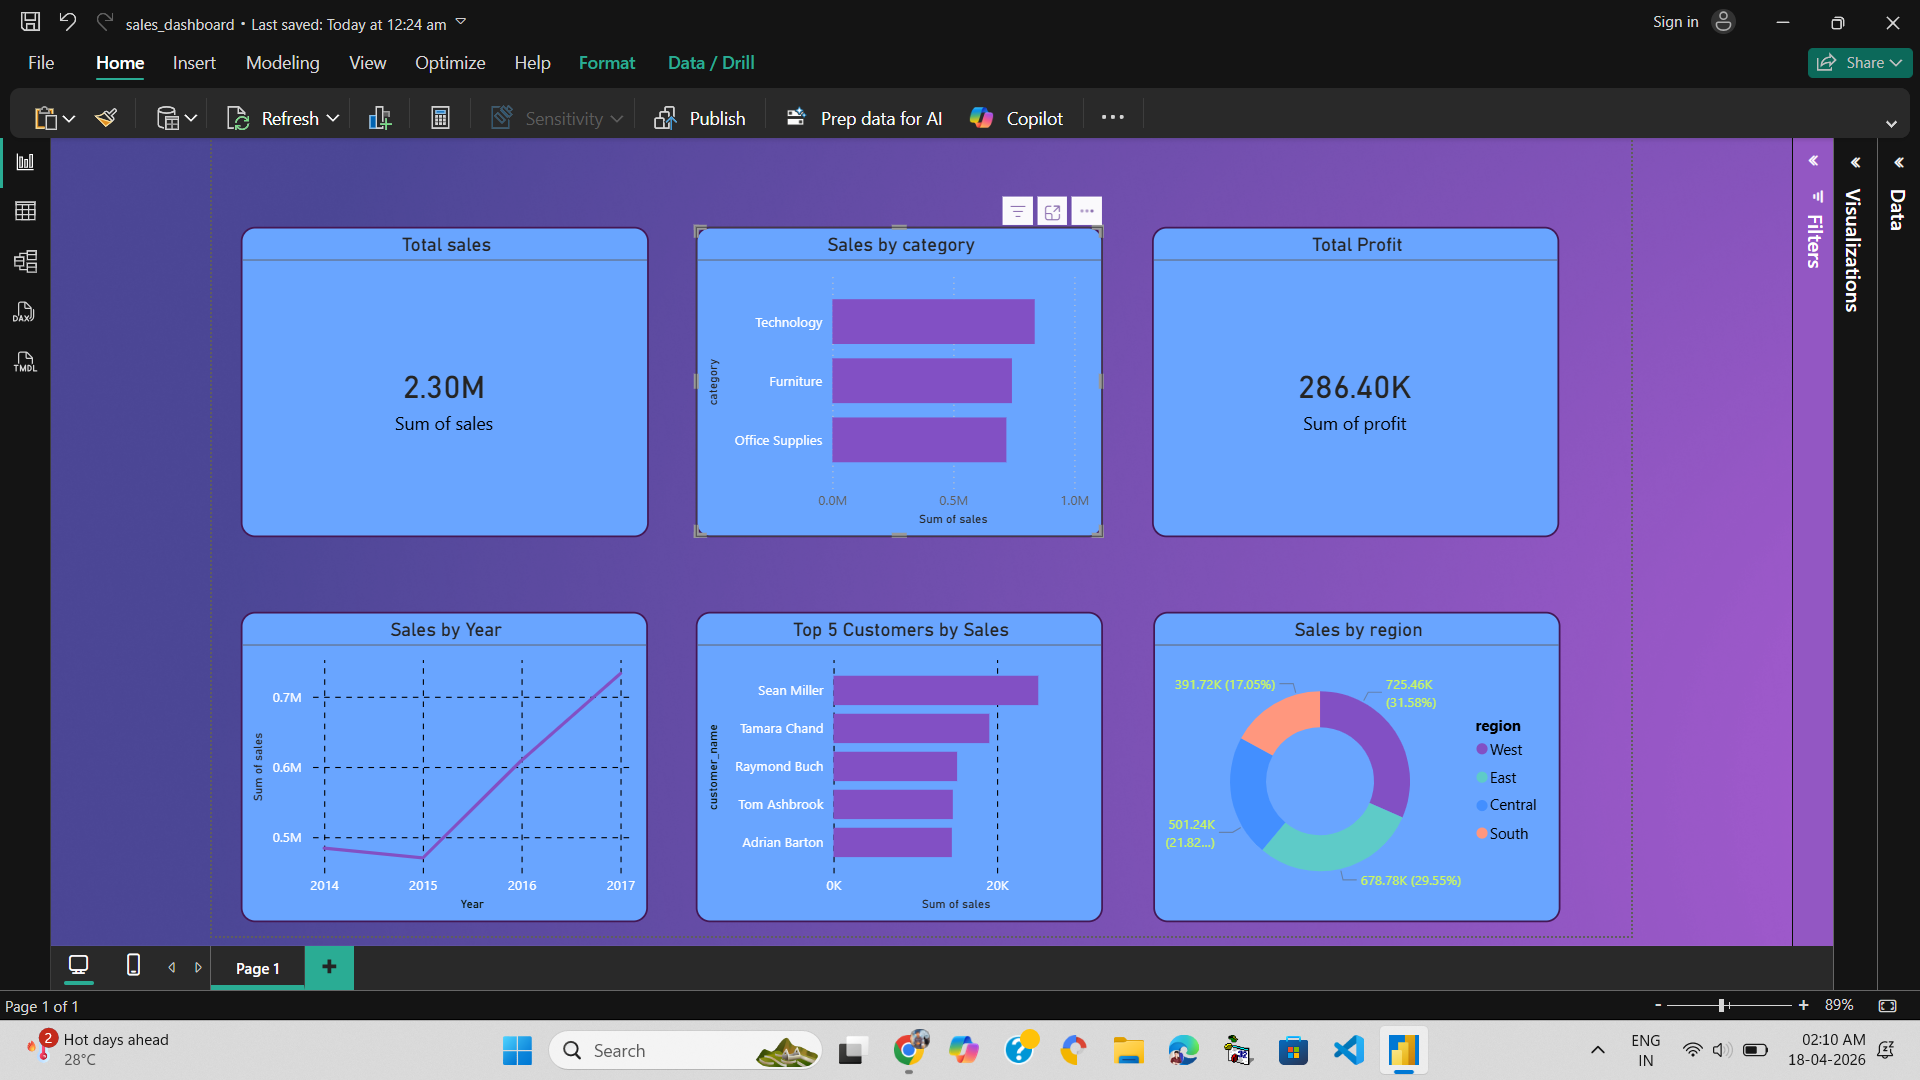

# **observation**
The dashboard shows total sales of ₹2.30M and total profit of ₹286K. Technology is the top-performing category with around ₹0.9M in sales, followed by Furniture and Office Supplies.

Sales have increased from ₹0.48M in 2015 to about ₹0.75M in 2017, indicating business growth. The West region leads with ~₹725K (31%), followed by East, Central, and South.

Top customers contribute up to ₹25K–₹30K, showing that a few customers drive major revenue. However, profit is relatively low compared to sales, suggesting a need to improve margins.

Overall, the business is growing, but profitability can be improved.

# **Conclusion **

In this task, EDA was performed on the Superstore dataset, showing total sales of ₹2.30M and profit of ₹286K. Technology emerged as the top category (~₹0.9M), and the West region led with around ₹725K (31%) in sales.

Sales showed steady growth from ₹0.48M in 2015 to ₹0.75M in 2017. SQL queries helped extract key business insights, and a Power BI dashboard was created to visualize performance.

Overall, the business is growing, but profit margins need improvement.